In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
import nltk
import re
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
from nltk.corpus import stopwords

print("All libraries loaded!")

All libraries loaded!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhuva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
df = pd.read_csv('data/Amazon-Product-Reviews.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nStar rating distribution:")
print(df['star_rating'].value_counts().sort_index())

Shape: (30846, 16)

Columns: ['marketplace', 'customer_id', 'review_id', 'product_id', 'product_parent', 'product_title', 'product_category', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'review_body', 'review_date', 'sentiment']

Missing values:
marketplace          0
customer_id          0
review_id            0
product_id           0
product_parent       0
product_title        0
product_category     0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_headline      2
review_body          4
review_date          0
sentiment            0
dtype: int64

Star rating distribution:
star_rating
1     1708
2     1155
3     2216
4     5748
5    20019
Name: count, dtype: int64


In [8]:
# Drop rows where review_body is empty
df = df.dropna(subset=['review_body'])

# Clean the review text
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)        # remove HTML tags like <br/>
    text = re.sub(r'[^a-z\s]', '', text)     # remove punctuation
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['clean_review'] = df['review_body'].apply(clean_text)

# Use star_rating column (your correct column name)
# Label ratings clearly
df['rating_label'] = df['star_rating'].apply(
    lambda x: 'Positive' if x >= 4 else ('Negative' if x <= 2 else 'Neutral')
)

print("Cleaning done!")
print("Reviews remaining:", len(df))
print("\nRating label distribution:")
print(df['rating_label'].value_counts())

Cleaning done!
Reviews remaining: 30842

Rating label distribution:
rating_label
Positive    25764
Negative     2862
Neutral      2216
Name: count, dtype: int64


In [9]:
def get_sentiment(text):
    score = TextBlob(str(text)).sentiment.polarity
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

def get_score(text):
    return TextBlob(str(text)).sentiment.polarity

df['textblob_sentiment'] = df['clean_review'].apply(get_sentiment)
df['sentiment_score'] = df['clean_review'].apply(get_score)

print("Sentiment analysis done!")
print("\nTextBlob sentiment distribution:")
print(df['textblob_sentiment'].value_counts())

Sentiment analysis done!

TextBlob sentiment distribution:
textblob_sentiment
Positive    24381
Neutral      5232
Negative     1229
Name: count, dtype: int64


In [10]:
df[['review_body', 'clean_review', 'star_rating', 
    'rating_label', 'textblob_sentiment', 
    'sentiment_score']].head()

,review_body,clean_review,star_rating,rating_label,textblob_sentiment,sentiment_score
0,Great love it,great love,5,Positive,Positive,0.650000
1,Lots of ads<br />Slow processing speed<br />Oc...,lots adsslow processing speedoccasionally shut...,3,Neutral,Positive,0.400000
2,Excellent unit. The versatility of this table...,excellent unit versatility tablet besides comp...,5,Positive,Positive,0.172917
3,I bought this on Amazon Prime so I ended up bu...,bought amazon prime ended buying gb one camera...,4,Positive,Positive,0.246875
4,All Amazon products continue to meet my expect...,amazon products continue meet expectations,5,Positive,Neutral,0.000000


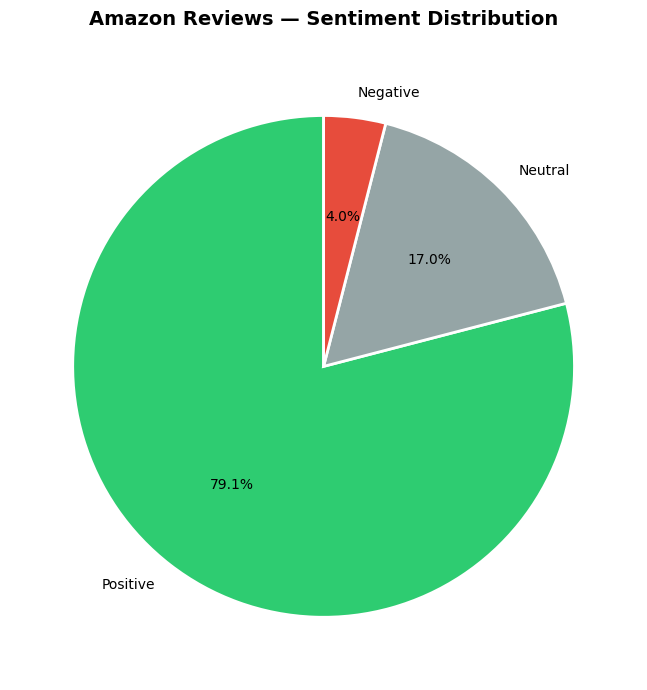

Chart 1 saved!


In [11]:
plt.figure(figsize=(7, 7))

colors = ['#2ecc71', '#95a5a6', '#e74c3c']
df['textblob_sentiment'].value_counts().plot(
    kind='pie',
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('Amazon Reviews — Sentiment Distribution', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('')
plt.tight_layout()
plt.savefig('images/01_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

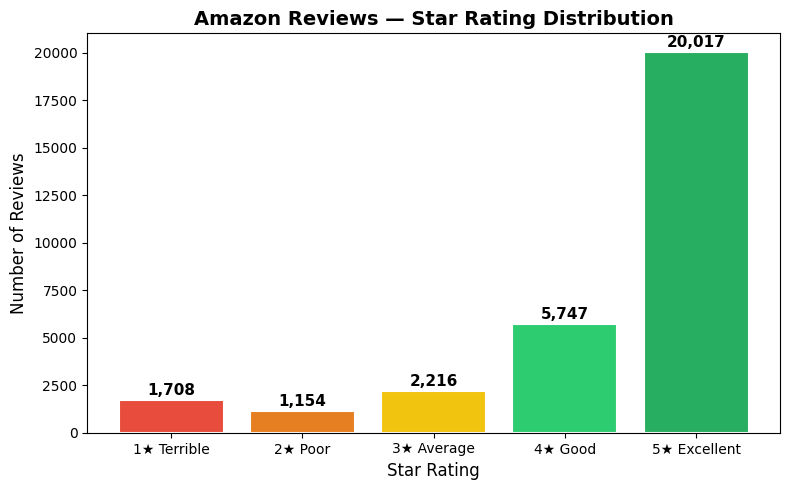

Chart 2 saved!


In [12]:
plt.figure(figsize=(8, 5))

rating_counts = df['star_rating'].value_counts().sort_index()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

bars = plt.bar(rating_counts.index, rating_counts.values, 
               color=colors, edgecolor='white', linewidth=1.5)

# Add value labels on top of each bar
for bar, val in zip(bars, rating_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 100,
             f'{val:,}', ha='center', va='bottom', 
             fontsize=11, fontweight='bold')

plt.title('Amazon Reviews — Star Rating Distribution', 
          fontsize=14, fontweight='bold')
plt.xlabel('Star Rating', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks([1, 2, 3, 4, 5], 
           ['1★ Terrible', '2★ Poor', '3★ Average', 
            '4★ Good', '5★ Excellent'])
plt.tight_layout()
plt.savefig('images/02_star_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

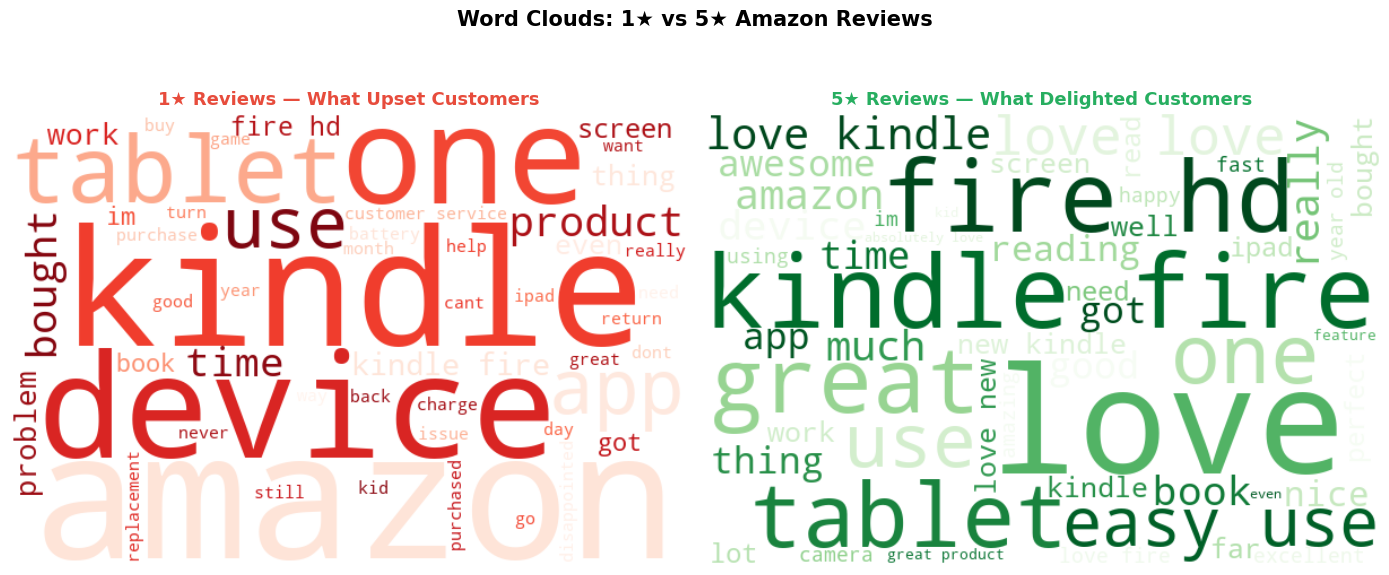

Chart 3 saved!


In [13]:
# Separate 1-star and 5-star reviews
one_star_text = ' '.join(df[df['star_rating'] == 1]['clean_review'].tolist())
five_star_text = ' '.join(df[df['star_rating'] == 5]['clean_review'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1-star word cloud
wc_negative = WordCloud(
    width=600, height=400,
    background_color='white',
    colormap='Reds',
    max_words=50
).generate(one_star_text)

axes[0].imshow(wc_negative, interpolation='bilinear')
axes[0].set_title('1★ Reviews — What Upset Customers', 
                   fontsize=13, fontweight='bold', color='#e74c3c')
axes[0].axis('off')

# 5-star word cloud
wc_positive = WordCloud(
    width=600, height=400,
    background_color='white',
    colormap='Greens',
    max_words=50
).generate(five_star_text)

axes[1].imshow(wc_positive, interpolation='bilinear')
axes[1].set_title('5★ Reviews — What Delighted Customers', 
                   fontsize=13, fontweight='bold', color='#27ae60')
axes[1].axis('off')

plt.suptitle('Word Clouds: 1★ vs 5★ Amazon Reviews', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/03_wordcloud_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

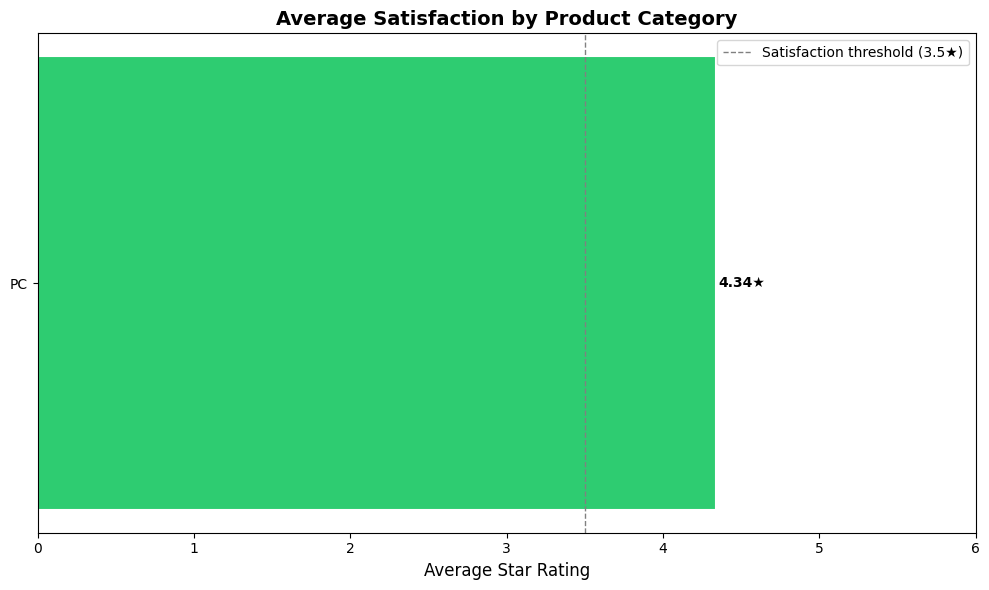

Chart 4 saved!


In [14]:
plt.figure(figsize=(10, 6))

category_rating = df.groupby('product_category')['star_rating'].mean().sort_values()

colors = ['#e74c3c' if x < 3.5 else '#2ecc71' for x in category_rating.values]

bars = plt.barh(category_rating.index, category_rating.values,
                color=colors, edgecolor='white', linewidth=1.5)

# Add value labels
for bar, val in zip(bars, category_rating.values):
    plt.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}★', va='center', fontsize=10, fontweight='bold')

plt.axvline(x=3.5, color='gray', linestyle='--', 
            linewidth=1, label='Satisfaction threshold (3.5★)')
plt.title('Average Satisfaction by Product Category', 
          fontsize=14, fontweight='bold')
plt.xlabel('Average Star Rating', fontsize=12)
plt.xlim(0, 6)
plt.legend()
plt.tight_layout()
plt.savefig('images/04_satisfaction_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

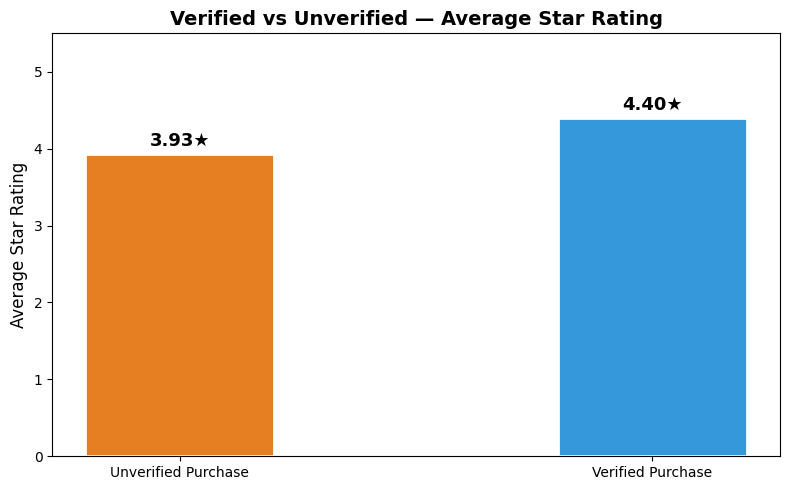

Chart 5 saved!


In [15]:
plt.figure(figsize=(8, 5))

verified_avg = df.groupby('verified_purchase')['star_rating'].mean()
verified_avg.index = ['Unverified Purchase', 'Verified Purchase']

colors = ['#e67e22', '#3498db']
bars = plt.bar(verified_avg.index, verified_avg.values,
               color=colors, edgecolor='white', 
               linewidth=2, width=0.4)

for bar, val in zip(bars, verified_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{val:.2f}★', ha='center', va='bottom',
             fontsize=13, fontweight='bold')

plt.title('Verified vs Unverified — Average Star Rating',
          fontsize=14, fontweight='bold')
plt.ylabel('Average Star Rating', fontsize=12)
plt.ylim(0, 5.5)
plt.tight_layout()
plt.savefig('images/05_verified_vs_unverified.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")